# Week 3 - Introduction to Machine Learning
**Name:** Rohit Kumar Gupta
**Internship Track:** AI
**Tasks covered in this notebook:** Task 2 (Dataset Preparation), Task 3 (Train-Test Split & Preprocessing), Task 4 (First ML Model)

> Task 1 (ML Fundamentals report) is in `Week3_Report.pdf` and Task 5 (Mini Project) is in the `Mini_Project` folder.

---
# Task 2: Dataset Preparation

For this task I am using a **Student Performance** dataset (`Dataset.csv`). It has 200 students and the columns are:

- `Student_ID` - id of the student
- `Study_Hours` - hours studied per day
- `Attendance` - attendance percentage
- `Previous_Marks` - marks in the previous exam
- `Assignment_Score` - score in assignments
- `Result` - Pass or Fail (this is what we want to predict)

### Step 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Load the dataset

In [2]:
df = pd.read_csv("Dataset.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


### Step 3: Display first 5 rows

In [3]:
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Result
0,S001,7.9,84.0,82.0,65.0,Pass
1,S002,4.7,69.0,69.0,82.0,Pass
2,S003,8.7,75.0,79.0,77.0,Pass
3,S004,7.1,73.0,NaN,45.0,Pass
4,S005,1.4,80.0,59.0,74.0,Fail


### Step 4: Check shape (rows, columns)

In [4]:
print("Shape of dataset:", df.shape)
print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])

Shape of dataset: (200, 6)
Number of rows   : 200
Number of columns: 6


### Step 5: Check data types

In [5]:
df.dtypes

Student_ID              str
Study_Hours         float64
Attendance          float64
Previous_Marks      float64
Assignment_Score    float64
Result                  str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        200 non-null    str    
 1   Study_Hours       194 non-null    float64
 2   Attendance        192 non-null    float64
 3   Previous_Marks    195 non-null    float64
 4   Assignment_Score  193 non-null    float64
 5   Result            200 non-null    str    
dtypes: float64(4), str(2)
memory usage: 9.5 KB


### Step 6: Identify missing values

In [7]:
print("Missing values in each column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values in each column:
Student_ID          0
Study_Hours         6
Attendance          8
Previous_Marks      5
Assignment_Score    7
Result              0
dtype: int64

Total missing values: 26


There are some missing values in `Study_Hours`, `Attendance`, `Previous_Marks` and `Assignment_Score`. ML models cannot work with empty (NaN) values so I need to handle them.

### Step 7: Remove / fill missing values
I have **two options**:
1. Remove the rows that have missing values (but then we lose data - we only have 200 rows).
2. Fill the missing values with the **mean** of that column.

I chose option 2 (fill with mean) so that I do not lose any student records.

In [8]:
# Fill missing values with the mean of each column
cols_to_fill = ["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]

for col in cols_to_fill:
    mean_value = df[col].mean()
    df[col] = df[col].fillna(mean_value)
    print(col, "-> filled with mean =", round(mean_value, 2))

Study_Hours -> filled with mean = 5.13
Attendance -> filled with mean = 74.67
Previous_Marks -> filled with mean = 65.35
Assignment_Score -> filled with mean = 69.19


In [9]:
# Check again
print(df.isnull().sum())
print()
print("Total missing values now:", df.isnull().sum().sum())

Student_ID          0
Study_Hours         0
Attendance          0
Previous_Marks      0
Assignment_Score    0
Result              0
dtype: int64

Total missing values now: 0


### Step 8: Identify features and target
- **Features (X)** = the input columns used to make a prediction: `Study_Hours`, `Attendance`, `Previous_Marks`, `Assignment_Score`
- **Target (y)** = the column we want to predict: `Result` (Pass / Fail)
- `Student_ID` is only an identifier so it is not useful for learning, I will not use it.

### Step 9: Separate dataset into X and y

In [10]:
X = df[["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score"]]
y = df["Result"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (200, 4)
Shape of y: (200,)


In [11]:
X.head()

,Study_Hours,Attendance,Previous_Marks,Assignment_Score
0,7.9,84.0,82.000000,65.0
1,4.7,69.0,69.000000,82.0
2,8.7,75.0,79.000000,77.0
3,7.1,73.0,65.348718,45.0
4,1.4,80.0,59.000000,74.0


In [12]:
print(y.head())
print()
print(y.value_counts())

0    Pass
1    Pass
2    Pass
3    Pass
4    Fail
Name: Result, dtype: str

Result
Pass    125
Fail     75
Name: count, dtype: int64


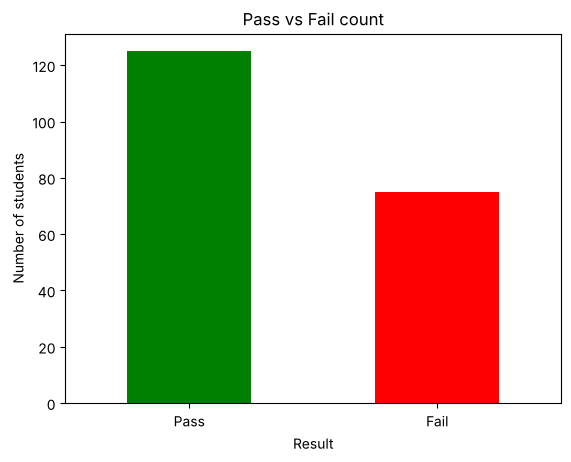

In [13]:
# small graph to see how many Pass and Fail students are there
y.value_counts().plot(kind="bar", color=["green", "red"])
plt.title("Pass vs Fail count")
plt.xlabel("Result")
plt.ylabel("Number of students")
plt.xticks(rotation=0)
plt.show()

**Short explanation (Task 2):**
I loaded the student dataset using Pandas and checked its shape (200 rows, 6 columns) and data types. I found missing values in four columns and filled them using the column mean so no data was lost. Then I selected 4 input features (X) and `Result` as the target (y).

---
# Task 3: Train-Test Split & Data Preprocessing

### Step 1: Import required libraries from Scikit-learn

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

### Step 2: Encode the target
The target `Result` has text values (Pass / Fail). Models work with numbers, so I convert it: **Fail = 0, Pass = 1**.

In [15]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", list(le.classes_))
print("Encoded values -> Fail = 0, Pass = 1")
print(y_encoded[:10])

Classes: ['Fail', 'Pass']
Encoded values -> Fail = 0, Pass = 1
[1 1 1 1 0 1 1 1 0 1]


### Step 3: Split data into training and testing sets
I used **test_size = 0.2** which means 80% of the data is used for training and 20% for testing. This is a commonly used split. `random_state = 42` is used so I get the same result every time I run the code. `stratify` keeps the Pass/Fail ratio similar in both sets.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Total samples   :", len(X))
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print()
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Total samples   : 200
Training samples: 160
Testing samples : 40

X_train shape: (160, 4)
X_test shape : (40, 4)
y_train shape: (160,)
y_test shape : (40,)


### Why do we divide data into training and testing sets?
If we train the model and test it on the **same data**, it can just memorize the answers and will show a very high score, but it may fail on new students. This is called **overfitting**.

So we keep a part of the data hidden (the test set). The model never sees it while learning. After training, we check the model on this unseen data, which tells us how well it will work in the real world.

**Flow:**

`Training Data  →  Model Learning  →  Testing Data  →  Prediction`

1. **Training Data** - 80% of data given to the model to learn the pattern.
2. **Model Learning** - the model finds the relation between features (study hours, attendance, etc.) and result.
3. **Testing Data** - the remaining 20% unseen data.
4. **Prediction** - model predicts Pass/Fail for the test data and we compare with the real answers.

### Step 4: Basic preprocessing - Feature Scaling
The features are on different scales (Study_Hours is 0-10 while Attendance is up to 100). Models like Logistic Regression work better when features are on a similar scale, so I use **StandardScaler**.

Important: I fit the scaler **only on the training data** and then use it to transform both train and test data. If I fit on the test data also, information from the test set would leak into training.

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from training data only
X_test_scaled = scaler.transform(X_test)         # use the same mean/std on test data

print("Before scaling (first 3 rows of X_train):")
print(X_train.head(3))
print()
print("After scaling (first 3 rows):")
print(np.round(X_train_scaled[:3], 3))

Before scaling (first 3 rows of X_train):
     Study_Hours  Attendance  Previous_Marks  Assignment_Score
105          7.3        54.0            83.0          69.00000
48           7.0       100.0            63.0          69.19171
111          2.4        93.0            70.0          76.00000

After scaling (first 3 rows):
[[ 0.801 -1.512  1.056 -0.049]
 [ 0.687  1.898 -0.131 -0.037]
 [-1.063  1.379  0.284  0.404]]


In [18]:
print("Mean of scaled training data:", np.round(X_train_scaled.mean(axis=0), 3))
print("Std of scaled training data :", np.round(X_train_scaled.std(axis=0), 3))

Mean of scaled training data: [-0. -0.  0. -0.]
Std of scaled training data : [1. 1. 1. 1.]


**Explanation of preprocessing (Task 3):**
- Missing values were already filled in Task 2.
- The target column (Pass/Fail) was converted into numbers (0/1) with `LabelEncoder`.
- The data was split 80/20 into train and test.
- Features were scaled with `StandardScaler` (mean becomes about 0 and std about 1). The scaler was fitted only on training data to avoid data leakage.

---
# Task 4: Build Your First Machine Learning Model

I chose **Option A - Classification** and used **Logistic Regression** on the student dataset (predict Pass / Fail).
I am also trying a **Decision Tree** on the famous **Iris** dataset to see how another classifier works.

## Part A: Logistic Regression on Student Data

### Step 1: Import the model and metrics

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Step 2: Train the model

In [20]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
print("Model trained successfully!")

Model trained successfully!


### Step 3: Make predictions on the test data

In [21]:
y_pred = model.predict(X_test_scaled)

print("Predicted :", y_pred[:15])
print("Actual    :", y_test[:15])

Predicted : [1 1 1 1 1 1 0 1 1 0 1 1 0 1 0]
Actual    : [0 1 1 1 0 1 0 1 1 0 1 1 0 1 0]


### Step 4: Display prediction results

In [22]:
results = X_test.copy()
results["Actual"] = le.inverse_transform(y_test)
results["Predicted"] = le.inverse_transform(y_pred)
results.head(10)

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Actual,Predicted
171,5.400000,63.0,56.0,62.0,Fail,Pass
35,2.300000,67.0,70.0,100.0,Pass,Pass
21,3.900000,94.0,86.0,73.0,Pass,Pass
141,5.130928,79.0,85.0,82.0,Pass,Pass
10,4.000000,63.0,63.0,80.0,Fail,Pass
83,2.100000,79.0,100.0,65.0,Pass,Pass
97,1.300000,39.0,69.0,33.0,Fail,Fail
136,9.600000,65.0,64.0,83.0,Pass,Pass
185,6.800000,93.0,50.0,71.0,Pass,Pass
192,1.700000,79.0,66.0,50.0,Fail,Fail


In [23]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc * 100, 2), "%")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

Accuracy: 85.0 %

Confusion Matrix:
[[12  3]
 [ 3 22]]

              precision    recall  f1-score   support

        Fail       0.80      0.80      0.80        15
        Pass       0.88      0.88      0.88        25

    accuracy                           0.85        40
   macro avg       0.84      0.84      0.84        40
weighted avg       0.85      0.85      0.85        40



Attendance          0.322243
Assignment_Score    0.420981
Previous_Marks      1.211588
Study_Hours         1.775933
dtype: float64


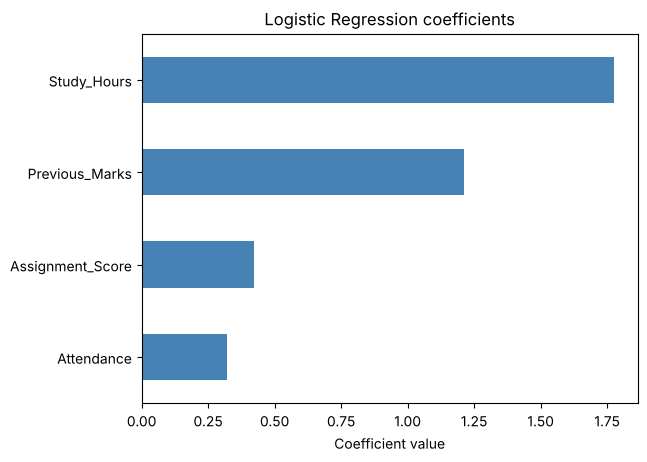

In [24]:
# which feature matters most? (look at the coefficients)
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(coef)
coef.plot(kind="barh", color="steelblue")
plt.title("Logistic Regression coefficients")
plt.xlabel("Coefficient value")
plt.show()

### How does Logistic Regression work?
Even though the name has "regression", Logistic Regression is used for **classification**. It takes the input features, multiplies each with a weight (coefficient), adds them up, and passes the result through a **sigmoid function** which gives a probability between 0 and 1.

- If the probability is 0.5 or more → predicts **Pass (1)**
- If the probability is less than 0.5 → predicts **Fail (0)**

During training the model adjusts the weights so that its predictions match the real results as closely as possible. The coefficients above show which features push the result towards Pass (positive) or Fail (negative).

## Part B: Decision Tree on Iris Dataset

In [25]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

print("Iris shape:", X_iris.shape)
print("Classes:", list(iris.target_names))
X_iris.head()

Iris shape: (150, 4)
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [26]:
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(Xi_train, yi_train)

yi_pred = tree.predict(Xi_test)
print("Predicted:", yi_pred)
print("Actual   :", yi_test)
print()
print("Accuracy:", round(accuracy_score(yi_test, yi_pred) * 100, 2), "%")

Predicted: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Actual   : [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Accuracy: 96.67 %


In [27]:
res = pd.DataFrame({
    "Actual": [iris.target_names[i] for i in yi_test],
    "Predicted": [iris.target_names[i] for i in yi_pred]
})
res.head(10)

,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


### How does a Decision Tree work?
A Decision Tree asks a series of yes/no questions about the features (for example "is petal length less than 2.45 cm?"). Each question splits the data into smaller groups. It keeps splitting until each group mostly contains one class. To predict, a new flower just follows the questions from the top (root) to the bottom (leaf) and gets the class of that leaf. I limited `max_depth=3` so that the tree does not become too complex and overfit.

## Conclusion
In this notebook I loaded and cleaned a dataset, separated features and target, split data into train and test, scaled the features and trained two classification models (Logistic Regression and Decision Tree). Both models gave good accuracy on unseen test data. This helped me understand the basic ML workflow: **Load → Clean → Split → Train → Predict → Evaluate**.